# Algebra 2005-2006（AL2005）知识追踪数据集说明

这个 Notebook 用来解释 `/root/autodl-tmp/ahs-kt/data/AL2005` 目录下刚下载的 Algebra 2005-2006 数据集：

- 先区分 **官方原始日志文件** 和 **已经预处理好的知识追踪序列文件**。
- 再解释核心字段、切分方式、`question-level` 与 `concept-level` 的区别。
- 最后给出可复用的读取、统计和样本解析代码。

> 说明：目录里的 `README.md` 基本没有数据说明，所以本 Notebook 的部分结论来自对文件名、表头、样本和统计量的交叉验证；凡是推断性质的地方会明确标注。

In [1]:
from pathlib import Path
import csv
import json
import math
import sys
from collections import Counter

import pandas as pd

csv.field_size_limit(sys.maxsize)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("/root/autodl-tmp/ahs-kt/data/AL2005").resolve()
assert DATA_DIR.exists(), f"数据目录不存在：{DATA_DIR}"
DATA_DIR

PosixPath('/root/autodl-tmp/ahs-kt/data/AL2005')

## 1. 目录结构

从文件名和内容看，这个目录可以分成四类：

1. **官方原始文件**：`algebra_2005_2006_train.txt`、`algebra_2005_2006_test.txt`、`algebra_2005_2006_master.txt`、`algebra_2005_2006.txt`。
2. **中间序列文件**：`data.txt`，按学生组织的 6 行一组文本序列。
3. **知识追踪预处理文件**：`train_valid*.csv`、`test*.csv`，已经把原始日志转换成按学生/窗口排列的序列。
4. **映射文件**：`keyid2idx.json`，保存原始 question、concept、uid 到整数 ID 的映射。

In [2]:
def format_bytes(num: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num)
    for unit in units:
        if size < 1024 or unit == units[-1]:
            return f"{size:.1f} {unit}"
        size /= 1024

file_table = pd.DataFrame([
    {
        "name": path.name,
        "size": format_bytes(path.stat().st_size),
        "bytes": path.stat().st_size,
        "suffix": path.suffix,
    }
    for path in sorted(DATA_DIR.iterdir())
    if path.is_file()
]).sort_values("name")

file_table[["name", "size", "suffix"]]

,name,size,suffix
0,.gitattributes,3.1 KB,
1,AL2005_dataset_guide.ipynb,44.2 KB,.ipynb
2,README.md,24.0 B,.md
3,algebra_2005_2006.txt,31.1 KB,.txt
4,algebra_2005_2006.zip,21.4 MB,.zip
5,algebra_2005_2006_master.txt,1.0 MB,.txt
6,algebra_2005_2006_test.txt,719.5 KB,.txt
7,algebra_2005_2006_train.txt,216.2 MB,.txt
8,data.txt,104.6 MB,.txt
9,keyid2idx.json,5.7 MB,.json


In [3]:
with (DATA_DIR / "keyid2idx.json").open("r", encoding="utf-8") as f:
    keyid2idx = json.load(f)

mapping_summary = {
    key: (len(value) if isinstance(value, dict) else value)
    for key, value in keyid2idx.items()
}
mapping_summary

{'questions': 173113, 'concepts': 112, 'uid': 574, 'max_concepts': 7}

## 2. 官方原始日志文件

官方原始表是 tab 分隔的 DataShop/KDD Cup 风格日志。核心文件含义如下：

- `algebra_2005_2006_train.txt`：有标签训练日志，包含学生做题步骤、时间、提示、错误次数和首次作答是否正确。
- `algebra_2005_2006_test.txt`：官方测试日志，目标列和时间/行为列被置空，用于预测 `Correct First Attempt`。
- `algebra_2005_2006_master.txt`：官方测试集的带答案版本；适合本地分析，不应当混入训练集做公平评测。
- `algebra_2005_2006.txt`：只有 `Row` 与空的 `Correct First Attempt`，更像提交模板。

原始表的关键字段：

- `Anon Student Id`：匿名学生 ID。
- `Problem Hierarchy`：课程单元和章节。
- `Problem Name`、`Problem View`、`Step Name`：题目、题目视图和具体步骤。
- `Step Start Time` 等时间列：学生开始、首次操作、正确操作和结束时间。
- `Correct First Attempt`：知识追踪最常用标签，首次尝试是否正确，`1` 表示正确，`0` 表示不正确。
- `Incorrects`、`Hints`、`Corrects`：该步骤中的错误、提示和正确操作次数。
- `KC(Default)`：默认知识组件/知识点；一行可能有多个 KC，用 `~~` 分隔。
- `Opportunity(Default)`：对应 KC 的练习机会次数；多 KC 时也用 `~~` 对齐。

In [4]:
def preview_text_file(name: str, n: int = 4, width: int = 220) -> None:
    path = DATA_DIR / name
    print(f"\n===== {name} =====")
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in zip(range(n), f):
            line = line.rstrip("\n")
            print(f"{i:02d}: {line[:width]!r}" + (" ..." if len(line) > width else ""))

for name in [
    "algebra_2005_2006_train.txt",
    "algebra_2005_2006_test.txt",
    "algebra_2005_2006_master.txt",
    "algebra_2005_2006.txt",
]:
    preview_text_file(name)


===== algebra_2005_2006_train.txt =====
00: 'Row\tAnon Student Id\tProblem Hierarchy\tProblem Name\tProblem View\tStep Name\tStep Start Time\tFirst Transaction Time\tCorrect Transaction Time\tStep End Time\tStep Duration (sec)\tCorrect Step Duration (sec)\tError Step Duration ' ...
01: '1\t0BrbPbwCMz\tUnit ES_04, Section ES_04-1\tEG4-FIXED\t1\t3(x+2) = 15\t2005-09-09 12:24:35.0\t2005-09-09 12:24:49.0\t2005-09-09 12:25:15.0\t2005-09-09 12:25:15.0\t40\t\t40\t0\t2\t3\t1\t[SkillRule: Eliminate Parens; {CLT nested; CLT neste' ...
02: '2\t0BrbPbwCMz\tUnit ES_04, Section ES_04-1\tEG4-FIXED\t1\tx+2 = 5\t2005-09-09 12:25:15.0\t2005-09-09 12:25:31.0\t2005-09-09 12:25:31.0\t2005-09-09 12:25:31.0\t16\t16\t\t1\t0\t0\t1\t[SkillRule: Remove constant; {ax+b=c, positive; ax+b=c, ' ...
03: '3\t0BrbPbwCMz\tUnit ES_04, Section ES_04-1\tEG40\t1\t2-8y = -4\t2005-09-09 12:25:36.0\t2005-09-09 12:25:43.0\t2005-09-09 12:26:12.0\t2005-09-09 12:26:12.0\t36\t\t36\t0\t2\t3\t1\t[SkillRule: Remove constant; {ax+b=c,

In [5]:
def summarize_raw_tab(name: str, chunksize: int = 100_000) -> dict:
    """分块统计原始 tab 文件，避免一次性读入 200MB+ 的长文本列。"""
    path = DATA_DIR / name
    usecols = [
        "Anon Student Id", "Problem Hierarchy", "Problem Name", "Step Name",
        "Step Start Time", "Correct First Attempt", "Incorrects", "Hints",
        "Corrects", "KC(Default)", "Opportunity(Default)",
    ]
    rows = 0
    students, problems, problem_steps, hierarchies, kcs = set(), set(), set(), set(), set()
    cfa_counter = Counter()
    hints_total = incorrects_total = corrects_total = 0
    multi_kc_rows = missing_kc_rows = 0
    start_min = start_max = None

    for chunk in pd.read_csv(
        path,
        sep="	",
        usecols=lambda column: column in usecols,
        dtype=str,
        chunksize=chunksize,
        low_memory=False,
    ):
        rows += len(chunk)
        students.update(chunk["Anon Student Id"].dropna().astype(str))
        problems.update(chunk["Problem Name"].dropna().astype(str))
        problem_steps.update((chunk["Problem Name"].fillna("") + "----" + chunk["Step Name"].fillna("")).astype(str))
        hierarchies.update(chunk["Problem Hierarchy"].dropna().astype(str))

        cfa = chunk["Correct First Attempt"].fillna("").astype(str)
        cfa_counter.update(cfa)

        hints_total += int(pd.to_numeric(chunk["Hints"], errors="coerce").fillna(0).sum())
        incorrects_total += int(pd.to_numeric(chunk["Incorrects"], errors="coerce").fillna(0).sum())
        corrects_total += int(pd.to_numeric(chunk["Corrects"], errors="coerce").fillna(0).sum())

        for value in chunk["KC(Default)"].fillna(""):
            if value == "":
                missing_kc_rows += 1
            else:
                parts = str(value).split("~~")
                multi_kc_rows += int(len(parts) > 1)
                kcs.update(parts)

        timestamps = pd.to_datetime(chunk["Step Start Time"], errors="coerce")
        if timestamps.notna().any():
            current_min, current_max = timestamps.min(), timestamps.max()
            start_min = current_min if start_min is None or current_min < start_min else start_min
            start_max = current_max if start_max is None or current_max > start_max else start_max

    labeled = cfa_counter["0"] + cfa_counter["1"]
    return {
        "file": name,
        "rows": rows,
        "students": len(students),
        "problems": len(problems),
        "problem_steps": len(problem_steps),
        "sections": len(hierarchies),
        "split_kcs": len(kcs),
        "correct_rate": cfa_counter["1"] / labeled if labeled else None,
        "missing_labels": cfa_counter[""],
        "missing_kc_rows": missing_kc_rows,
        "multi_kc_rows": multi_kc_rows,
        "hints_total": hints_total,
        "incorrects_total": incorrects_total,
        "corrects_total": corrects_total,
        "start_min": str(start_min) if start_min is not None else None,
        "start_max": str(start_max) if start_max is not None else None,
    }

raw_summary = pd.DataFrame([
    summarize_raw_tab("algebra_2005_2006_train.txt"),
    summarize_raw_tab("algebra_2005_2006_test.txt"),
    summarize_raw_tab("algebra_2005_2006_master.txt"),
])
raw_summary

,file,rows,students,problems,problem_steps,sections,split_kcs,correct_rate,missing_labels,missing_kc_rows,multi_kc_rows,hints_total,incorrects_total,corrects_total,start_min,start_max
0,algebra_2005_2006_train.txt,809694,574,1084,210710,138,112,0.766514,0,202669,190514,244919,408309,950718,2005-08-30 09:43:32,2006-06-07 11:12:31
1,algebra_2005_2006_test.txt,3967,575,686,3239,131,98,NaN,3967,1013,919,0,0,0,None,None
2,algebra_2005_2006_master.txt,3967,575,686,3239,131,98,0.787245,0,1013,919,1092,1706,4589,2005-08-30 11:04:29,2006-06-07 11:12:38


### 原始表的当前统计结论

在当前目录中，原始训练表的关键规模是：

- `algebra_2005_2006_train.txt` 有 **809,694** 条步骤日志、**574** 名学生、**1,084** 个 problem name、拆分后 **112** 个 KC。
- 训练日志时间跨度约为 **2005-08-30 到 2006-06-07**。
- 训练日志的 `Correct First Attempt` 正确率约为 **76.65%**。
- 有 **202,669** 行没有 `KC(Default)`；知识追踪预处理通常会丢掉这些无 KC 行。
- 有 **190,514** 行包含多个 KC；转成 concept-level 序列时通常会展开为多条 concept 交互。

## 3. KT 预处理文件：为什么有 `train_valid.csv` 和 `test.csv`？

这里最容易误解的一点是：目录里的 `test.csv` **不是** 官方 `algebra_2005_2006_test.txt` 的简单 CSV 版本。

根据以下事实可以推断：

- `test.csv` 里有完整的 `responses` 标签，而官方 `algebra_2005_2006_test.txt` 的目标列是空的。
- `train_valid.csv` 有 460 个学生，`test.csv` 有 114 个学生，合计 **574**，正好等于官方训练表中的学生数。
- `train_valid.csv` 的 `fold` 为 `0~4`，每折 92 个学生；`test.csv` 的 `fold` 为 `-1`。

因此，本目录中的 `train_valid*.csv` / `test*.csv` 更像是：**从官方有标签训练日志中，先过滤无 KC 行，再按学生切出的 KT 训练/验证/测试序列**。官方测试/答案文件仍然保留在目录中，但不一定参与这些 KT 预处理 CSV 的生成。

In [6]:
def count_raw_kc_rows(name: str = "algebra_2005_2006_train.txt") -> dict:
    """核对原始训练日志过滤/展开后与 KT CSV 的交互数是否一致。"""
    path = DATA_DIR / name
    non_missing_kc_rows = 0
    expanded_concept_interactions = 0
    for chunk in pd.read_csv(path, sep="	", usecols=["KC(Default)"], dtype=str, chunksize=100_000):
        for value in chunk["KC(Default)"].fillna(""):
            if value:
                parts = str(value).split("~~")
                non_missing_kc_rows += 1
                expanded_concept_interactions += len(parts)
    return {
        "raw_rows_with_kc": non_missing_kc_rows,
        "raw_rows_after_concept_expansion": expanded_concept_interactions,
    }

raw_kc_counts = count_raw_kc_rows()
raw_kc_counts

{'raw_rows_with_kc': 607025, 'raw_rows_after_concept_expansion': 884102}

这个核对非常重要：

- 原始训练日志中有 KC 的行数是 **607,025**。
- 将多 KC 行按 `~~` 展开后，总 concept-level 交互数是 **884,102**。
- `train_valid_quelevel.csv` + `test_quelevel.csv` 的交互数合计也是 **607,025**。
- `train_valid.csv` + `test.csv` 的交互数合计也是 **884,102**。

所以可以把两套预处理理解为：

- **question-level / quelevel**：一条原始“题目步骤”保留为一个时间步，多 KC 用下划线组合，例如 `31_30_33`。
- **concept-level**：一条多 KC 原始步骤会展开成多个时间步；`is_repeat` 用来标记这些由同一原始步骤展开出来的重复项。

## 4. 预处理 CSV 字段解释

常见字段含义：

- `fold`：训练/验证折号；`0~4` 表示 5 折中的折号，`-1` 表示 hold-out test。
- `uid`：重映射后的学生整数 ID。
- `questions`：重映射后的 question 序列；通常由原始 `Problem Name` + `Step Name` 组合而来。
- `concepts`：重映射后的 KC/concept 序列；`_quelevel` 文件中，一个 question 可能对应 `31_30_33` 这样的多 concept 组合。
- `responses`：作答结果序列，`1` 为首次尝试正确，`0` 为首次尝试不正确。
- `timestamps`：毫秒级 Unix 时间戳，来自原始时间列。
- `is_repeat`：concept-level 展开后的重复标记；同一原始 question 拆成多 concept 时，后续 concept 通常会被标为重复。
- `selectmasks`：固定长度序列中的有效/可选位置；`-1` 通常表示 padding 或不参与预测/损失的位置。
- `cidxs`：推断为 concept-level 序列在原始未切窗序列中的位置索引。
- `qidxs`、`rest`、`orirow`：只出现在 `test_question_sequences*.csv`，推断用于把 concept-level 预测聚合回 question-level 评测；`qidxs` 标记所属 question，`rest` 标记同一 question 还剩多少 concept，`orirow` 用于回溯原始行/窗口。

In [7]:
def split_values(text) -> list:
    if text is None:
        return []
    text = str(text)
    if text == "" or text.lower() == "nan":
        return []
    return text.split(",")


def split_nonpad(text) -> list:
    return [value for value in split_values(text) if value not in {"", "-1"}]


def quantile(sorted_values, q: float):
    if not sorted_values:
        return None
    position = (len(sorted_values) - 1) * q
    low = int(math.floor(position))
    high = int(math.ceil(position))
    if low == high:
        return sorted_values[low]
    return sorted_values[low] * (high - position) + sorted_values[high] * (position - low)


def summarize_sequence_csv(name: str) -> dict:
    path = DATA_DIR / name
    rows = 0
    users = set()
    folds = Counter()
    total_interactions = 0
    correct = 0
    questions = set()
    concepts = set()
    lengths = []
    repeat_total = repeat_yes = 0
    padded_rows = padding_tokens = 0

    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows += 1
            users.add(row["uid"])
            folds[row["fold"]] += 1

            responses = split_values(row.get("responses", ""))
            valid_len = sum(value not in {"", "-1"} for value in responses)
            lengths.append(valid_len)
            total_interactions += valid_len
            correct += sum(value == "1" for value in responses)

            questions.update(split_nonpad(row.get("questions", "")))
            concepts.update(split_nonpad(row.get("concepts", "")))

            if "is_repeat" in row:
                repeats = split_values(row.get("is_repeat", ""))
                repeat_total += sum(value not in {"", "-1"} for value in repeats)
                repeat_yes += sum(value == "1" for value in repeats)

            padding_tokens += sum(value == "-1" for value in responses)
            padded_rows += int(any(value == "-1" for value in responses))

    sorted_lengths = sorted(lengths)
    return {
        "file": name,
        "rows": rows,
        "users": len(users),
        "folds": dict(folds),
        "interactions": total_interactions,
        "correct_rate": correct / total_interactions if total_interactions else None,
        "unique_questions": len(questions),
        "unique_concepts": len(concepts),
        "len_min": min(lengths) if lengths else None,
        "len_median": quantile(sorted_lengths, 0.5),
        "len_mean": total_interactions / rows if rows else None,
        "len_p95": quantile(sorted_lengths, 0.95),
        "len_max": max(lengths) if lengths else None,
        "repeat_rate": repeat_yes / repeat_total if repeat_total else None,
        "padded_rows": padded_rows,
        "padding_tokens": padding_tokens,
    }

sequence_files = [
    "train_valid.csv",
    "test.csv",
    "train_valid_sequences.csv",
    "test_sequences.csv",
    "train_valid_quelevel.csv",
    "test_quelevel.csv",
    "train_valid_sequences_quelevel.csv",
    "test_sequences_quelevel.csv",
]

sequence_summary = pd.DataFrame([summarize_sequence_csv(name) for name in sequence_files])
sequence_summary

,file,rows,users,folds,interactions,correct_rate,unique_questions,unique_concepts,len_min,len_median,len_mean,len_p95,len_max,repeat_rate,padded_rows,padding_tokens
0,train_valid.csv,460,460,"{'0': 92, '1': 92, '2': 92, '3': 92, '4': 92}",748694,0.714725,150260,112,6,843.5,1627.595652,5480.60,9926,0.314233,0,0
1,test.csv,114,114,{'-1': 114},135408,0.712196,35866,110,20,672.5,1187.789474,4715.20,6718,0.308793,0,0
2,train_valid_sequences.csv,3980,460,"{'0': 870, '1': 872, '2': 782, '3': 751, '4': 705}",748692,0.714724,150260,112,3,200.0,188.113568,200.00,200,0.314233,456,47308
3,test_sequences.csv,732,114,{'-1': 732},135406,0.712191,35866,110,3,200.0,184.980874,200.00,200,0.308797,112,10994
4,train_valid_quelevel.csv,460,460,"{'0': 92, '1': 92, '2': 92, '3': 92, '4': 92}",513430,0.755036,150260,427,3,590.0,1116.152174,3723.80,7021,NaN,0,0
5,test_quelevel.csv,114,114,{'-1': 114},93595,0.756675,35866,299,18,482.0,821.008772,3251.95,4543,NaN,0,0
6,train_valid_sequences_quelevel.csv,2811,460,"{'0': 614, '1': 617, '2': 555, '3': 528, '4': 497}",513419,0.755032,150256,427,3,200.0,182.646389,200.00,200,NaN,452,48781
7,test_sequences_quelevel.csv,529,114,{'-1': 529},93594,0.756683,35866,299,4,200.0,176.926276,200.00,200,NaN,113,12206


### 当前预处理 CSV 的规模

当前目录的主要预处理文件统计如下：

- `train_valid.csv`：460 个学生，748,694 个 concept-level 交互，5 折各 92 个学生。
- `test.csv`：114 个学生，135,408 个 concept-level 交互，`fold=-1`。
- `train_valid_sequences.csv` / `test_sequences.csv`：把长序列切成最大长度约 200 的模型输入序列，含 `selectmasks` 和 padding。
- `_quelevel.csv`：question-level 序列，交互数少于 concept-level，因为多 KC 不再展开为多个时间步。
- 映射文件显示全量有 173,113 个 question ID、112 个 concept ID、574 个 uid，`max_concepts=7`。

In [8]:
def parse_first_row(name: str) -> pd.DataFrame:
    path = DATA_DIR / name
    with path.open("r", newline="", encoding="utf-8") as f:
        row = next(csv.DictReader(f))

    records = []
    for column, value in row.items():
        values = split_values(value)
        records.append({
            "column": column,
            "num_tokens": len(values),
            "first_12_tokens": values[:12],
            "last_5_tokens": values[-5:] if values else [],
        })
    return pd.DataFrame(records)

parse_first_row("test.csv")

,column,num_tokens,first_12_tokens,last_5_tokens
0,fold,1,[-1],[-1]
1,uid,1,[438],[438]
2,questions,306,"[3331, 3331, 3331, 3333, 3334, 3335, 3332, 3339, 3340, 3341, 3341, 3341]","[3495, 3495, 3501, 3502, 3499]"
3,concepts,306,"[31, 30, 33, 41, 41, 42, 41, 25, 24, 26, 31, 27]","[28, 30, 40, 40, 41]"
4,responses,306,"[1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0]","[1, 1, 1, 1, 1]"
5,timestamps,306,"[1140572833000, 1140572833000, 1140572833000, 1140572883000, 1140572913000, 1140572928000, 1140572982000, 1140573093...","[1146016440000, 1146016440000, 1146016541000, 1146016554000, 1146016577000]"
6,is_repeat,306,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]","[1, 1, 0, 0, 0]"
7,cidxs,306,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[301, 302, 303, 304, 305]"


In [9]:
parse_first_row("test_quelevel.csv")

,column,num_tokens,first_12_tokens,last_5_tokens
0,fold,1,[-1],[-1]
1,uid,1,[438],[438]
2,questions,213,"[3331, 3333, 3334, 3335, 3332, 3339, 3340, 3341, 3342, 3347, 3344, 3348]","[3485, 3495, 3501, 3502, 3499]"
3,concepts,213,"[31_30_33, 41, 41, 42, 41, 25, 24, 26_31_27, 29, 26_31_37, 29, 26_31_37]","[29, 26_28_30, 40, 40, 41]"
4,responses,213,"[1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1]","[1, 1, 1, 1, 1]"
5,timestamps,213,"[1140572833000, 1140572883000, 1140572913000, 1140572928000, 1140572982000, 1140573093000, 1140573109000, 1140573124...","[1146016438000, 1146016440000, 1146016541000, 1146016554000, 1146016577000]"


In [10]:
parse_first_row("test_question_sequences.csv")

,column,num_tokens,first_12_tokens,last_5_tokens
0,fold,1,[-1],[-1]
1,uid,1,[438],[438]
2,questions,200,"[3331, 3331, 3331, 3333, 3334, 3335, 3332, 3339, 3340, 3341, -1, -1]","[-1, -1, -1, -1, -1]"
3,concepts,200,"[31, 30, 33, 41, 41, 42, 41, 25, 24, 26, -1, -1]","[-1, -1, -1, -1, -1]"
4,responses,200,"[1, 1, 1, 1, 0, 1, 1, 1, 1, 0, -1, -1]","[-1, -1, -1, -1, -1]"
5,timestamps,200,"[1140572833000, 1140572833000, 1140572833000, 1140572883000, 1140572913000, 1140572928000, 1140572982000, 1140573093...","[-1, -1, -1, -1, -1]"
6,selectmasks,200,"[-1, -1, -1, 1, 1, 1, 1, 1, 1, 1, -1, -1]","[-1, -1, -1, -1, -1]"
7,is_repeat,200,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, -1, -1]","[-1, -1, -1, -1, -1]"
8,qidxs,200,"[0, 0, 0, 1, 2, 3, 4, 5, 6, 7, -1, -1]","[-1, -1, -1, -1, -1]"
9,rest,200,"[2, 1, 0, 0, 0, 0, 0, 0, 0, 2, -1, -1]","[-1, -1, -1, -1, -1]"



## 附加：数据分布可视化

下面这组单元把前面算出的统计结果变成**可视化表格**和**分布图**，帮助你快速理解：

- 原始日志与预处理文件在规模上差多少；
- 学生交互长度、正确率、重复展开比例的大致分布；
- concept-level 中哪些 concept 最常见；
- question-level 中一题对应多少个 concept；
- 固定长度 `*_sequences.csv` 里 padding 有多少。


In [11]:

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.unicode_minus'] = False


In [12]:

raw_table = raw_summary.set_index('file').copy()
display(
    raw_table.style
    .format({
        'rows': '{:,.0f}',
        'students': '{:,.0f}',
        'problems': '{:,.0f}',
        'problem_steps': '{:,.0f}',
        'sections': '{:,.0f}',
        'split_kcs': '{:,.0f}',
        'correct_rate': '{:.2%}',
        'missing_labels': '{:,.0f}',
        'missing_kc_rows': '{:,.0f}',
        'multi_kc_rows': '{:,.0f}',
        'hints_total': '{:,.0f}',
        'incorrects_total': '{:,.0f}',
        'corrects_total': '{:,.0f}',
    })
    .background_gradient(subset=['rows', 'students', 'problems', 'problem_steps', 'sections', 'split_kcs'], cmap='Blues')
    .background_gradient(subset=['correct_rate'], cmap='YlGn')
    .background_gradient(subset=['missing_kc_rows', 'multi_kc_rows'], cmap='OrRd')
)

sequence_table = sequence_summary.set_index('file').copy()
display(
    sequence_table.style
    .format({
        'rows': '{:,.0f}',
        'users': '{:,.0f}',
        'interactions': '{:,.0f}',
        'correct_rate': '{:.2%}',
        'unique_questions': '{:,.0f}',
        'unique_concepts': '{:,.0f}',
        'len_min': '{:,.0f}',
        'len_median': '{:,.1f}',
        'len_mean': '{:,.1f}',
        'len_p95': '{:,.1f}',
        'len_max': '{:,.0f}',
        'repeat_rate': '{:.2%}',
        'padded_rows': '{:,.0f}',
        'padding_tokens': '{:,.0f}',
    })
    .background_gradient(subset=['rows', 'users', 'interactions', 'unique_questions', 'unique_concepts'], cmap='PuBu')
    .background_gradient(subset=['correct_rate', 'repeat_rate'], cmap='YlGn')
    .background_gradient(subset=['padded_rows', 'padding_tokens'], cmap='YlOrRd')
)


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

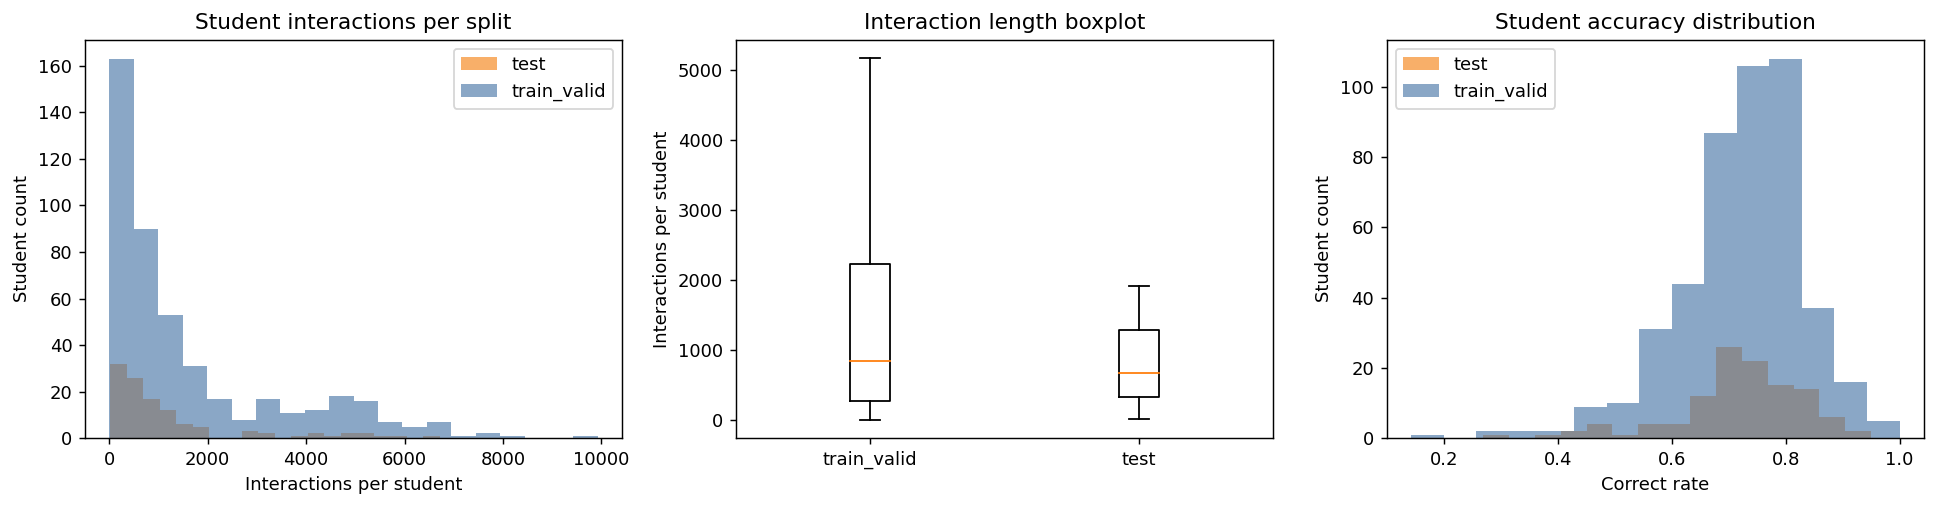

In [13]:

def build_student_level_stats(csv_name: str, split_name: str):
    df = pd.read_csv(DATA_DIR / csv_name)
    records = []
    question_counter = Counter()
    concept_counter = Counter()
    response_counter = Counter()

    for row in df.itertuples(index=False):
        question_tokens = split_nonpad(row.questions)
        concept_tokens = split_nonpad(row.concepts)
        response_tokens = split_nonpad(row.responses)
        repeat_tokens = split_nonpad(getattr(row, 'is_repeat', ''))

        if not response_tokens:
            continue

        question_counter.update(question_tokens)
        concept_counter.update(concept_tokens)
        response_counter.update(response_tokens)

        response_int = [int(value) for value in response_tokens]
        repeat_int = [int(value) for value in repeat_tokens] if repeat_tokens else []
        records.append({
            'split': split_name,
            'uid': int(row.uid),
            'interactions': len(response_int),
            'correct_rate': float(np.mean(response_int)),
            'repeat_rate': float(np.mean(repeat_int)) if repeat_int else np.nan,
        })

    return pd.DataFrame(records), question_counter, concept_counter, response_counter

train_student_stats, train_question_counter, train_concept_counter, train_response_counter = build_student_level_stats('train_valid.csv', 'train_valid')
test_student_stats, test_question_counter, test_concept_counter, test_response_counter = build_student_level_stats('test.csv', 'test')
student_stats = pd.concat([train_student_stats, test_student_stats], ignore_index=True)

student_dist_table = student_stats.groupby('split').agg(
    users=('uid', 'nunique'),
    interactions_mean=('interactions', 'mean'),
    interactions_median=('interactions', 'median'),
    interactions_p95=('interactions', lambda s: s.quantile(0.95)),
    interactions_max=('interactions', 'max'),
    correct_rate_mean=('correct_rate', 'mean'),
    repeat_rate_mean=('repeat_rate', 'mean'),
)

display(
    student_dist_table.style
    .format({
        'users': '{:,.0f}',
        'interactions_mean': '{:,.1f}',
        'interactions_median': '{:,.1f}',
        'interactions_p95': '{:,.1f}',
        'interactions_max': '{:,.0f}',
        'correct_rate_mean': '{:.2%}',
        'repeat_rate_mean': '{:.2%}',
    })
    .background_gradient(subset=['users', 'interactions_mean', 'interactions_median', 'interactions_p95', 'interactions_max'], cmap='Blues')
    .background_gradient(subset=['correct_rate_mean', 'repeat_rate_mean'], cmap='YlGn')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'train_valid': '#4c78a8', 'test': '#f58518'}

for split_name, group in student_stats.groupby('split'):
    axes[0].hist(group['interactions'], bins=20, alpha=0.65, label=split_name, color=colors[split_name])
    axes[2].hist(group['correct_rate'], bins=15, alpha=0.65, label=split_name, color=colors[split_name])

axes[0].set_title('Student interactions per split')
axes[0].set_xlabel('Interactions per student')
axes[0].set_ylabel('Student count')
axes[0].legend()

axes[1].boxplot(
    [student_stats.loc[student_stats['split'] == 'train_valid', 'interactions'],
     student_stats.loc[student_stats['split'] == 'test', 'interactions']],
    labels=['train_valid', 'test'],
    showfliers=False,
)
axes[1].set_title('Interaction length boxplot')
axes[1].set_ylabel('Interactions per student')

axes[2].set_title('Student accuracy distribution')
axes[2].set_xlabel('Correct rate')
axes[2].set_ylabel('Student count')
axes[2].legend()

plt.tight_layout()
plt.show()


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

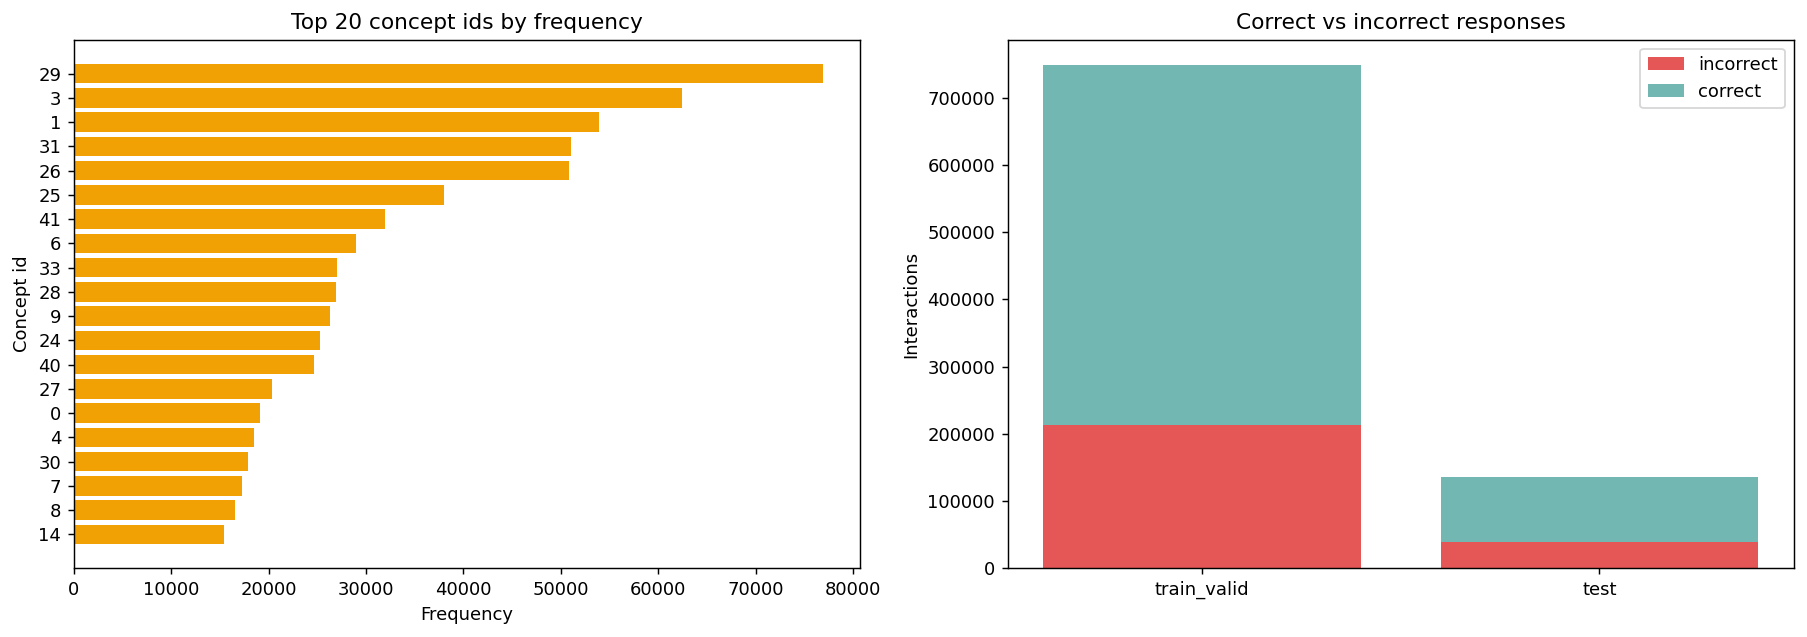

In [14]:

overall_concept_counter = train_concept_counter + test_concept_counter
top_concepts_df = pd.DataFrame(overall_concept_counter.most_common(20), columns=['concept_id', 'count'])

response_dist_df = pd.DataFrame([
    {
        'split': 'train_valid',
        'incorrect': train_response_counter['0'],
        'correct': train_response_counter['1'],
    },
    {
        'split': 'test',
        'incorrect': test_response_counter['0'],
        'correct': test_response_counter['1'],
    },
])
response_dist_df['total'] = response_dist_df['incorrect'] + response_dist_df['correct']
response_dist_df['correct_rate'] = response_dist_df['correct'] / response_dist_df['total']

display(
    top_concepts_df.style
    .format({'count': '{:,.0f}'})
    .background_gradient(subset=['count'], cmap='Oranges')
)

display(
    response_dist_df.style
    .format({'incorrect': '{:,.0f}', 'correct': '{:,.0f}', 'total': '{:,.0f}', 'correct_rate': '{:.2%}'})
    .background_gradient(subset=['incorrect', 'correct', 'total'], cmap='PuBu')
    .background_gradient(subset=['correct_rate'], cmap='YlGn')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_concepts_df['concept_id'].astype(str), top_concepts_df['count'], color='#f2a104')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 concept ids by frequency')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Concept id')

x = np.arange(len(response_dist_df))
axes[1].bar(x, response_dist_df['incorrect'], label='incorrect', color='#e45756')
axes[1].bar(x, response_dist_df['correct'], bottom=response_dist_df['incorrect'], label='correct', color='#72b7b2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(response_dist_df['split'])
axes[1].set_title('Correct vs incorrect responses')
axes[1].set_ylabel('Interactions')
axes[1].legend()

plt.tight_layout()
plt.show()


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

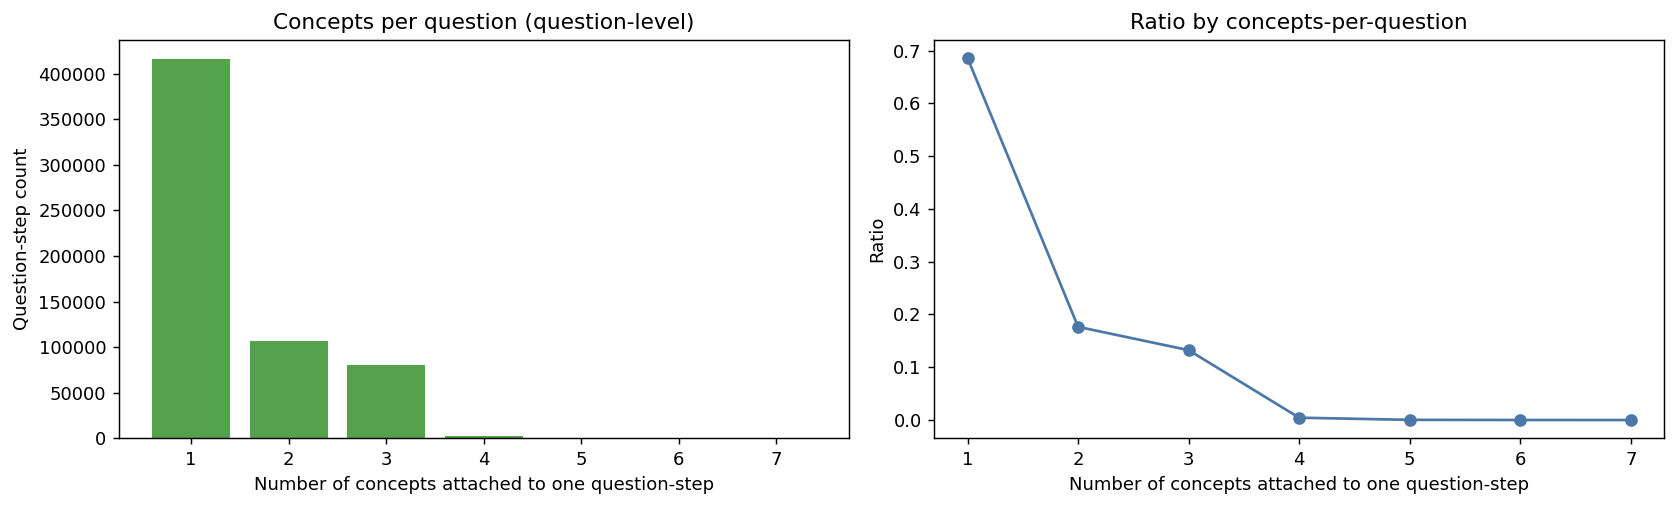

In [15]:

def build_question_kc_cardinality(csv_name: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / csv_name, usecols=['uid', 'concepts', 'responses'])
    records = []
    for row in df.itertuples(index=False):
        concept_tokens = split_nonpad(row.concepts)
        response_tokens = split_nonpad(row.responses)
        valid_len = min(len(concept_tokens), len(response_tokens))
        for token in concept_tokens[:valid_len]:
            concept_count = len(str(token).split('_')) if token else 0
            records.append({
                'split': split_name,
                'concepts_per_question': concept_count,
            })
    return pd.DataFrame(records)

question_kc_stats = pd.concat([
    build_question_kc_cardinality('train_valid_quelevel.csv', 'train_valid_quelevel'),
    build_question_kc_cardinality('test_quelevel.csv', 'test_quelevel'),
], ignore_index=True)

question_kc_table = (
    question_kc_stats.groupby(['split', 'concepts_per_question'])
    .size()
    .rename('count')
    .reset_index()
    .pivot(index='concepts_per_question', columns='split', values='count')
    .fillna(0)
    .astype(int)
)
question_kc_table['overall'] = question_kc_table.sum(axis=1)
question_kc_table['overall_ratio'] = question_kc_table['overall'] / question_kc_table['overall'].sum()

display(
    question_kc_table.style
    .format({'train_valid_quelevel': '{:,.0f}', 'test_quelevel': '{:,.0f}', 'overall': '{:,.0f}', 'overall_ratio': '{:.2%}'})
    .background_gradient(subset=['train_valid_quelevel', 'test_quelevel', 'overall'], cmap='GnBu')
    .background_gradient(subset=['overall_ratio'], cmap='YlGn')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(question_kc_table.index.astype(str), question_kc_table['overall'], color='#54a24b')
axes[0].set_title('Concepts per question (question-level)')
axes[0].set_xlabel('Number of concepts attached to one question-step')
axes[0].set_ylabel('Question-step count')

axes[1].plot(question_kc_table.index.to_numpy(), question_kc_table['overall_ratio'].to_numpy(), marker='o', color='#4c78a8')
axes[1].set_title('Ratio by concepts-per-question')
axes[1].set_xlabel('Number of concepts attached to one question-step')
axes[1].set_ylabel('Ratio')

plt.tight_layout()
plt.show()


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

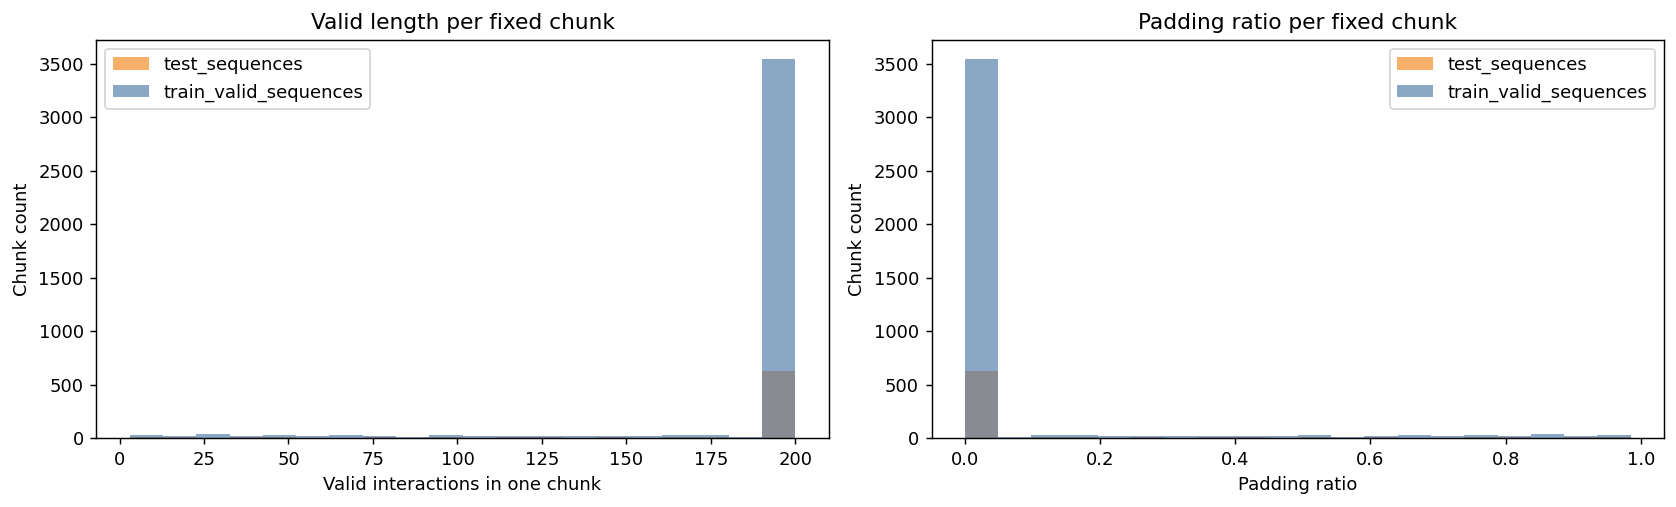

In [16]:

def build_chunk_level_stats(csv_name: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / csv_name, usecols=['uid', 'responses', 'selectmasks'])
    records = []
    for row in df.itertuples(index=False):
        response_tokens = split_values(row.responses)
        mask_tokens = split_values(row.selectmasks)
        valid_len = sum(token not in {'', '-1'} for token in response_tokens)
        padding_len = sum(token == '-1' for token in response_tokens)
        selected_len = sum(token == '1' for token in mask_tokens)
        total_len = len(response_tokens)
        records.append({
            'split': split_name,
            'uid': int(row.uid),
            'valid_len': valid_len,
            'padding_len': padding_len,
            'selected_len': selected_len,
            'padding_ratio': padding_len / total_len if total_len else np.nan,
        })
    return pd.DataFrame(records)

chunk_stats = pd.concat([
    build_chunk_level_stats('train_valid_sequences.csv', 'train_valid_sequences'),
    build_chunk_level_stats('test_sequences.csv', 'test_sequences'),
], ignore_index=True)

chunk_table = chunk_stats.groupby('split').agg(
    chunks=('uid', 'size'),
    valid_len_mean=('valid_len', 'mean'),
    valid_len_median=('valid_len', 'median'),
    valid_len_p95=('valid_len', lambda s: s.quantile(0.95)),
    padding_mean=('padding_len', 'mean'),
    padding_ratio_mean=('padding_ratio', 'mean'),
)

display(
    chunk_table.style
    .format({
        'chunks': '{:,.0f}',
        'valid_len_mean': '{:,.1f}',
        'valid_len_median': '{:,.1f}',
        'valid_len_p95': '{:,.1f}',
        'padding_mean': '{:,.1f}',
        'padding_ratio_mean': '{:.2%}',
    })
    .background_gradient(subset=['chunks', 'valid_len_mean', 'valid_len_median', 'valid_len_p95'], cmap='PuBu')
    .background_gradient(subset=['padding_mean', 'padding_ratio_mean'], cmap='YlOrRd')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {'train_valid_sequences': '#4c78a8', 'test_sequences': '#f58518'}

for split_name, group in chunk_stats.groupby('split'):
    axes[0].hist(group['valid_len'], bins=20, alpha=0.65, label=split_name, color=colors[split_name])
    axes[1].hist(group['padding_ratio'], bins=20, alpha=0.65, label=split_name, color=colors[split_name])

axes[0].set_title('Valid length per fixed chunk')
axes[0].set_xlabel('Valid interactions in one chunk')
axes[0].set_ylabel('Chunk count')
axes[0].legend()

axes[1].set_title('Padding ratio per fixed chunk')
axes[1].set_xlabel('Padding ratio')
axes[1].set_ylabel('Chunk count')
axes[1].legend()

plt.tight_layout()
plt.show()



### 如何读这些图

可以优先关注下面几个问题：

- 如果学生交互长度分布很长尾，说明训练时最好使用切窗、mask，不能简单按完整序列硬喂模型。
- 如果 `concepts_per_question > 1` 的比例不低，说明 question-level 和 concept-level 的定义差异会显著影响样本数。
- 如果最后一个固定长度 chunk 的 padding 比例较高，说明很多学生序列末尾并没有刚好填满 200。
- 如果某些 concept 的出现频次远高于其他 concept，模型可能会更偏向高频知识点，需要关注长尾 concept 表现。


## 5. `data.txt`：6 行一组的中间序列

`data.txt` 的行数是 574 × 6，正好对应 574 个学生，每个学生 6 行。根据样本内容推断其格式为：

1. `student_id,sequence_length`
2. 原始 question 字符串序列
3. 原始 concept/KC 字符串序列
4. response 序列
5. timestamp 序列
6. 额外占位字段，这个目录中样本多为 `NA`

这个文件保留的是未整数化或半结构化的中间结果；实际建模通常优先使用已经整数化的 CSV。

In [17]:
def preview_data_txt_student(student_index: int = 0, width: int = 180) -> pd.DataFrame:
    path = DATA_DIR / "data.txt"
    start = student_index * 6
    rows = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line_number, line in enumerate(f):
            if start <= line_number < start + 6:
                text = line.rstrip("\n")
                rows.append({
                    "block_line": line_number - start + 1,
                    "chars": len(text),
                    "preview": text[:width] + ("..." if len(text) > width else ""),
                })
            if line_number >= start + 5:
                break
    return pd.DataFrame(rows)

preview_data_txt_student(0)

,block_line,chars,preview
0,1,14,"0BrbPbwCMz,587"
1,2,14376,"EG4-FIXED----3(x+2) = 15,EG4-FIXED----x+2 = 5,EG40----2-8y = -4,EG40-----8y = -6,EG40-----7y-5 = -4,EG40-----7y = 1,..."
2,3,134824,[SkillRule: Eliminate Parens; {CLT nested; CLT nested@@@@ parens; Distribute Mult right; Distribute Mult left; (+/-x...
3,4,1173,"0,1,0,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,..."
4,5,8217,"1126239889000,1126239931000,1126239943000,1126239994000,1126240116000,1126240123000,1126240149000,1126240154000,1126..."
5,6,2,NA


## 6. 推荐用法

根据建模目标选择文件：

- **普通 DKT/SAKT/AKT concept-level 建模**：优先从 `train_valid_sequences.csv` 和 `test_sequences.csv` 开始，字段已经是定长序列，概念 ID 是单值。
- **question-level 建模或按题评测**：使用 `train_valid_sequences_quelevel.csv` 和 `test_sequences_quelevel.csv`；注意 `concepts` 可能是 `31_30_33` 这种多 concept 组合。
- **需要自己做切窗/时间特征/特征工程**：使用 `train_valid.csv` 和 `test.csv`，它们保留每个学生的完整长序列。
- **需要还原官方任务或做原始日志分析**：使用 `algebra_2005_2006_train.txt`、`algebra_2005_2006_test.txt` 和 `algebra_2005_2006_master.txt`。

建模时需要特别注意：

- 不要把 `algebra_2005_2006_master.txt` 混进训练集，否则会泄漏官方测试答案。
- 预处理 CSV 中的 `test.csv` 是从有标签训练日志切出的 hold-out 测试集，不等同于官方无标签测试表。
- 固定长度序列里 `-1` 是 padding，训练损失和指标计算时要用 `selectmasks` 或显式 mask 排除。
- concept-level 文件中 `is_repeat=1` 的位置通常来自同一道题的多 KC 展开；如果按 question 计算指标，需要避免重复计数。

In [18]:
# 一个最小读取示例：把第一条定长序列转成可直接喂给模型的 Python list。

def to_int_list(text: str, drop_padding: bool = False) -> list:
    values = [int(value) for value in str(text).split(",") if value != ""]
    if drop_padding:
        values = [value for value in values if value != -1]
    return values

sample = pd.read_csv(DATA_DIR / "train_valid_sequences.csv", nrows=1).iloc[0]
example = {
    "uid": int(sample["uid"]),
    "fold": int(sample["fold"]),
    "questions": to_int_list(sample["questions"]),
    "concepts": to_int_list(sample["concepts"]),
    "responses": to_int_list(sample["responses"]),
    "selectmasks": to_int_list(sample["selectmasks"]),
    "is_repeat": to_int_list(sample["is_repeat"]),
}
{k: (len(v) if isinstance(v, list) else v) for k, v in example.items()}

{'uid': 314,
 'fold': 0,
 'questions': 200,
 'concepts': 200,
 'responses': 200,
 'selectmasks': 200,
 'is_repeat': 200}

In [19]:
# 如果只想保留非 padding 的有效位置，可以这样过滤。
valid_positions = [i for i, mask in enumerate(example["selectmasks"]) if mask != -1]
filtered_example = {
    "questions": [example["questions"][i] for i in valid_positions],
    "concepts": [example["concepts"][i] for i in valid_positions],
    "responses": [example["responses"][i] for i in valid_positions],
}
{k: (len(v), v[:10]) for k, v in filtered_example.items()}

{'questions': (200, [602, 604, 605, 603, 606, 606, 606, 607, 607, 607]),
 'concepts': (200, [25, 25, 25, 24, 26, 27, 28, 26, 31, 27]),
 'responses': (200, [1, 1, 1, 1, 0, 0, 0, 0, 0, 0])}

## 7. 小结

这个目录同时保存了官方原始日志和一个已经为知识追踪模型整理好的序列版本。最核心的处理链路可以概括为：

1. 从官方训练日志 `algebra_2005_2006_train.txt` 出发。
2. 丢掉没有 `KC(Default)` 的原始步骤。
3. question-level：保留 607,025 条有 KC 的原始步骤。
4. concept-level：把多 KC 步骤展开，得到 884,102 条 concept 交互。
5. 按学生切分成 460 个 `train_valid` 学生和 114 个 hold-out `test` 学生。
6. 再按最大长度约 200 生成 `*_sequences.csv`，用于直接喂给 KT 模型。